# Horse Colic Dataset:


## Can you predict the life or death of a horse?
https://www.kaggle.com/uciml/horse-colic


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
#dataset = pd.read_csv('horse.csv', header = 0)

#https://drive.google.com/file/d/1UToozWGqS_6u2zYTbDc-ysSmO_QT-Joh/view?usp=sharing
file_id = '1UToozWGqS_6u2zYTbDc-ysSmO_QT-Joh'
url = f'https://drive.google.com/uc?id={file_id}'
dataset = pd.read_csv(url, header = 0)

dataset.head()

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


# **Comprensión de los datos**

In [ ]:
dataset.shape

(299, 28)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surgery                299 non-null    object 
 1   age                    299 non-null    object 
 2   hospital_number        299 non-null    int64  
 3   rectal_temp            239 non-null    float64
 4   pulse                  275 non-null    float64
 5   respiratory_rate       241 non-null    float64
 6   temp_of_extremities    243 non-null    object 
 7   peripheral_pulse       230 non-null    object 
 8   mucous_membrane        252 non-null    object 
 9   capillary_refill_time  267 non-null    object 
 10  pain                   244 non-null    object 
 11  peristalsis            255 non-null    object 
 12  abdominal_distention   243 non-null    object 
 13  nasogastric_tube       195 non-null    object 
 14  nasogastric_reflux     193 non-null    object 
 15  nasoga

In [ ]:
dataset.isnull() # Otra forma de detectar missing values

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,False,False,False,False,False,False,False,False,True,False,...,False,False,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,True,False,False,...,False,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,False,False,False,True,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,False,False
295,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


<Axes: >

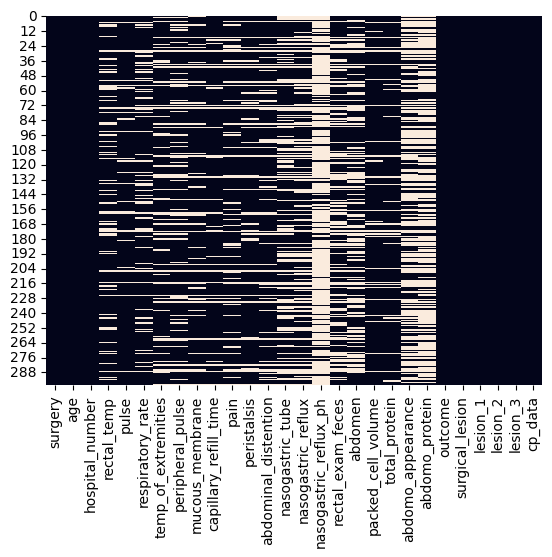

In [ ]:
sns.heatmap(dataset.isnull(), cbar=False) # Otra forma de detectar missing values

<Axes: >

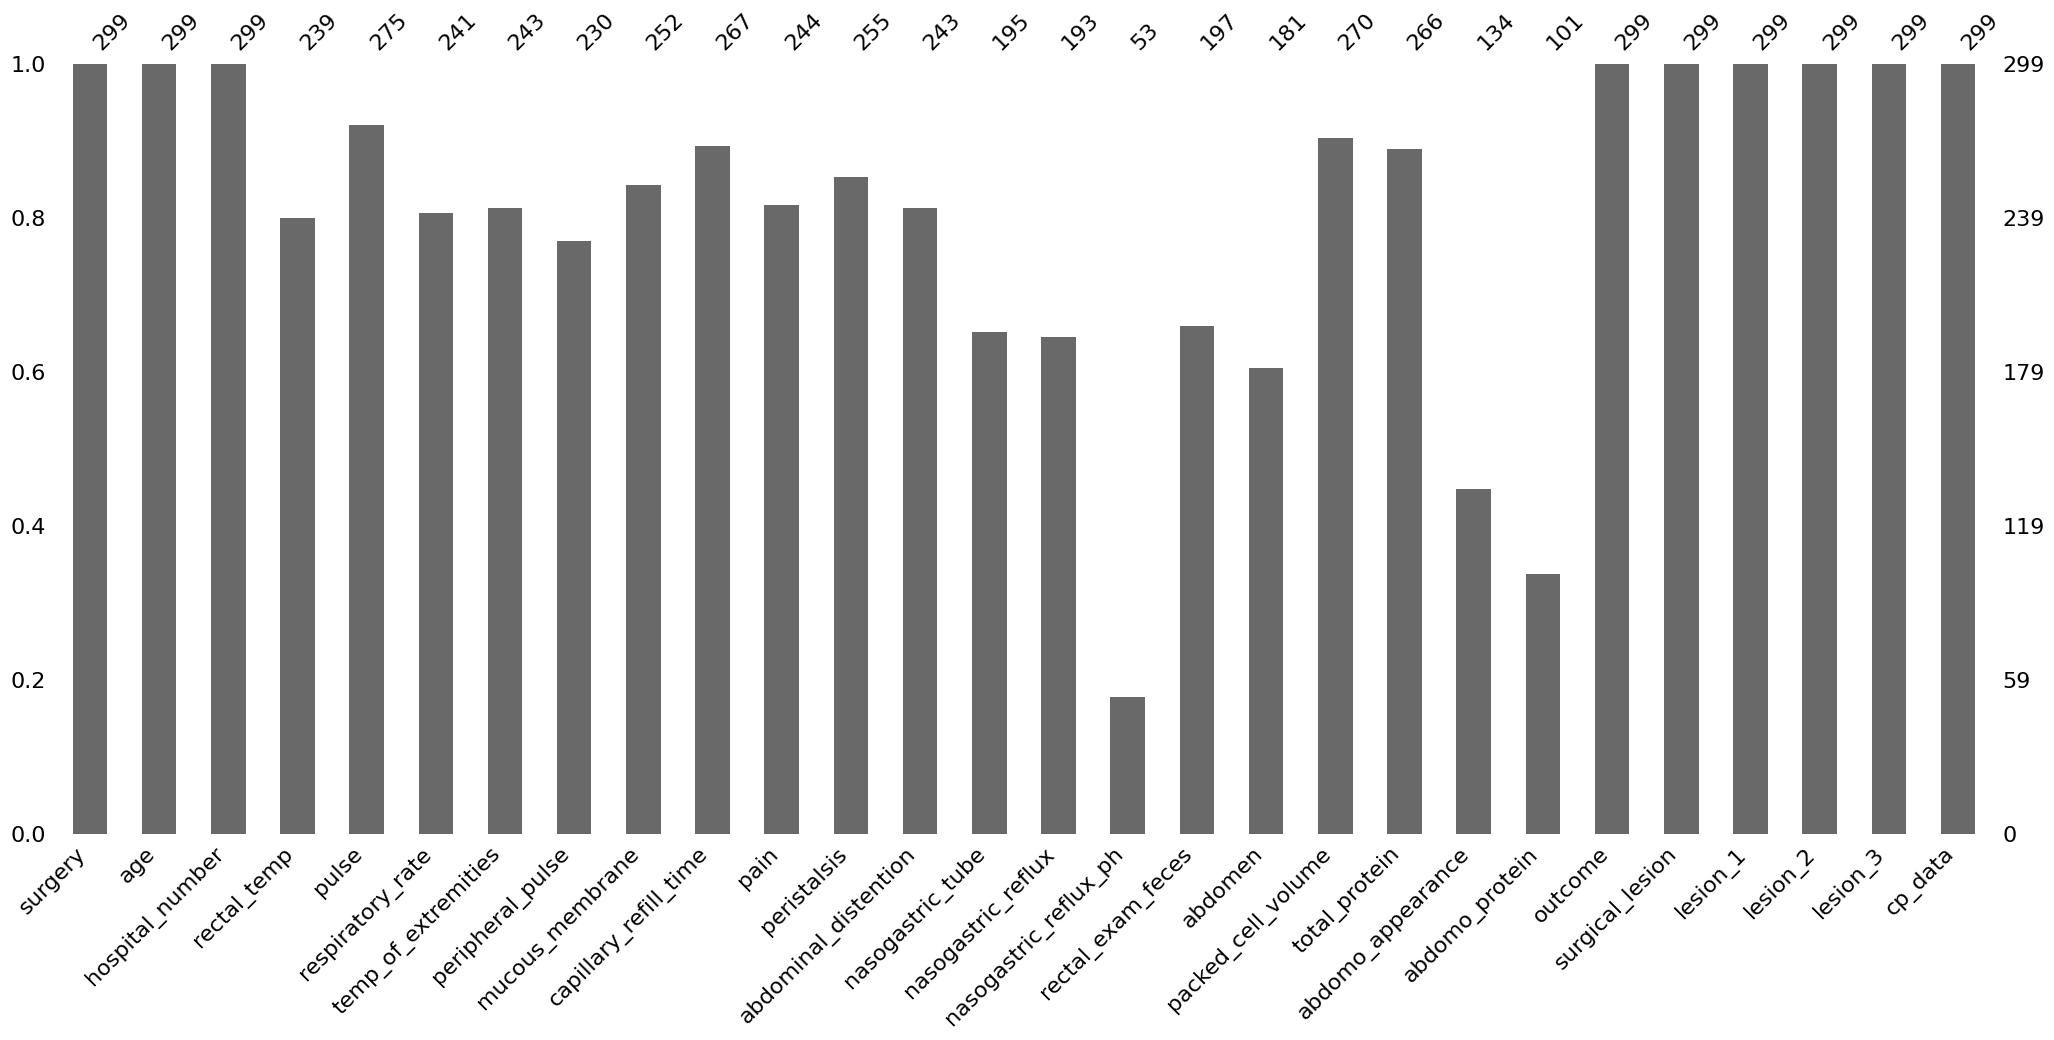

In [ ]:
import missingno as msno

msno.bar(dataset)

# **Limpieza de datos**

##**SURGERY**

**1 = Yes, it had surgery**

**2 = It was treated without surgery**

In [ ]:
dataset['surgery'].value_counts()

,count
surgery,
yes,180
no,119


In [ ]:
dataset['surgery'] = dataset['surgery'].map({'yes': 1, 'no':0})

In [ ]:
dataset.head()

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,0,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,1,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,0,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,1,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,0,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


##**AGE**

**1 = Adult horse**

**2 = Young (< 6 months)**

In [ ]:
dataset['age'].value_counts()

,count
age,
adult,275
young,24


In [ ]:
dataset['age'] = dataset['age'].map({'adult': 1, 'young':0})
dataset['age'].value_counts()

,count
age,
1,275
0,24


##**Hospital Number: The case number assigned to the horse (may not be unique if the horse is treated > 1 time)**



In [ ]:
dataset['hospital_number'].value_counts()

,count
hospital_number,
527544,2
528996,2
532349,2
529796,2
528890,2
...,...
530002,1
534135,1
534145,1


In [ ]:
# No nos aporta mucha información
# En todo caso puede ser interesante el número de hospitalizaciones (NH)

dataset['NH'] = dataset['hospital_number'].map(lambda x: (dataset['hospital_number'] == x).sum())
dataset = dataset.drop(['hospital_number'], axis=1)

In [ ]:
dataset['NH'].value_counts()

,count
NH,
1,267
2,32


##**Pulse**

In [ ]:
nan_per=dataset['pulse'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

8.03  % valores nulos


<Axes: xlabel='outcome', ylabel='pulse'>

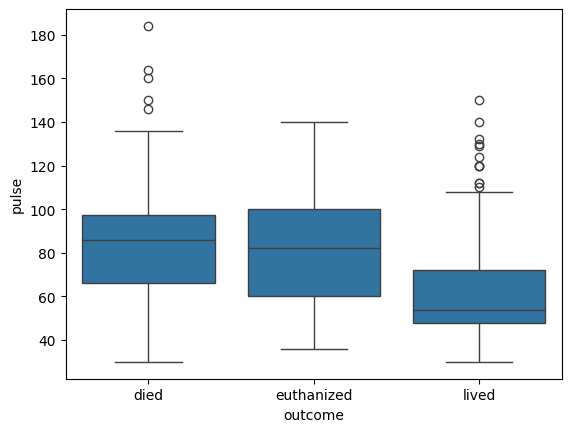

In [ ]:
sns.boxplot(x='outcome', y='pulse', data = dataset)

In [ ]:
dataset.pulse.describe()

,pulse
count,275.000000
mean,72.000000
std,28.646219
min,30.000000
25%,48.000000
50%,64.000000
75%,88.000000
max,184.000000


In [ ]:
# Simplemente consideramos la media:
dataset['pulse']=dataset['pulse'].fillna(dataset['pulse'].mean())

In [ ]:
# Podemos considerar normal 1 (48-88), alto 2 (> 88), bajo 3 (< 48)
dataset.pulse.describe()


,pulse
count,299.000000
mean,72.000000
std,27.468469
min,30.000000
25%,48.500000
50%,68.000000
75%,88.000000
max,184.000000


##**Respiratory Rate**

In [ ]:
nan_per=dataset['respiratory_rate'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

19.4  % valores nulos


<Axes: xlabel='outcome', ylabel='respiratory_rate'>

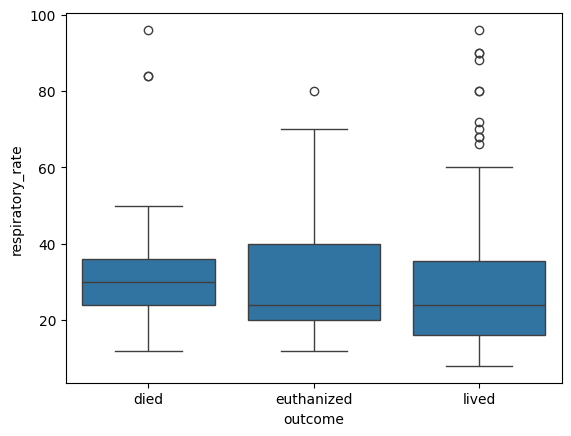

In [ ]:
sns.boxplot(x='outcome', y='respiratory_rate', data = dataset)

In [ ]:
dataset.respiratory_rate.describe()

,respiratory_rate
count,241.000000
mean,30.460581
std,17.666102
min,8.000000
25%,18.000000
50%,25.000000
75%,36.000000
max,96.000000


In [ ]:
# Simplemente consideramos la media:
dataset['respiratory_rate']=dataset['respiratory_rate'].fillna(dataset['respiratory_rate'].mean())

In [ ]:
dataset.respiratory_rate.describe()

,respiratory_rate
count,299.000000
mean,30.460581
std,15.853977
min,8.000000
25%,20.000000
50%,30.000000
75%,34.500000
max,96.000000


##**Temperature of Extremities**

In [ ]:
nan_per=dataset['temp_of_extremities'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

18.73  % valores nulos


In [ ]:
dataset.temp_of_extremities.value_counts()

,count
temp_of_extremities,
cool,108
normal,78
warm,30
cold,27


In [ ]:
# El valor mas repetido es cool asi que introducimos ese valor en todas las ocurencias que están a NaN
dataset['temp_of_extremities'].fillna('cool' , inplace=True)
dataset['temp_of_extremities']=dataset['temp_of_extremities'].astype('category').cat.codes
dataset['temp_of_extremities'].unique()

/tmp/ipython-input-3808486961.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['temp_of_extremities'].fillna('cool' , inplace=True)


array([1, 2, 0, 3], dtype=int8)

##**Rectal Temperature**

<Axes: xlabel='outcome', ylabel='rectal_temp'>

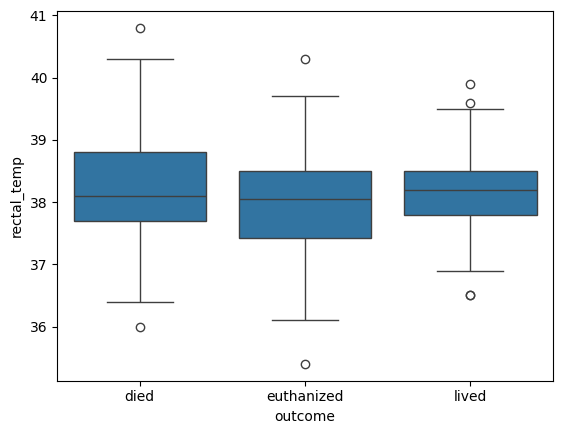

In [ ]:
# Vemos que relación tienen con cp_data, la variable objetivo

sns.boxplot(x='outcome', y='rectal_temp', data = dataset)

In [ ]:
# Y el total y el porcentaje de valores nulos

dataset['rectal_temp'].isna().value_counts()

,count
rectal_temp,
False,239
True,60


In [ ]:
nan_per=dataset['rectal_temp'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

20.07  % valores nulos


Para rellenar los valores nulos tenemos varias posibilidades:

In [ ]:
# Vamos a usar RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor

# Consideramos que influyen los siguientes campos:
dataset_sub = dataset[['rectal_temp', 'pulse','respiratory_rate','temp_of_extremities']]

# Dividimos la base de datos en dos grupos:
# por un lado la temperatura, que lo ponemos en y,
# y lo que nos sirve para predecir la temperatura, que lo ponemos en X (en X ponemos las variable y en y el target).
# Y en ambos casos se ejecuta dropna para eliminar los valores nulos.
X_train  = dataset_sub.dropna(subset=['rectal_temp']).drop('rectal_temp', axis=1)
y_train  = dataset['rectal_temp'].dropna()
X_test = dataset_sub.loc[np.isnan(dataset_sub.rectal_temp)].drop('rectal_temp', axis=1)

#Aplicamos el algortimo
regressor = RandomForestRegressor(n_estimators = 300)
regressor.fit(X_train, y_train)
#Predecimos los valores que nos faltan
y_pred = np.round(regressor.predict(X_test),1)
dataset.rectal_temp.loc[np.isnan(dataset.rectal_temp)] = y_pred


/tmp/ipython-input-1715239380.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset.rectal_temp.loc[np.isnan(dataset.rectal_temp)] = y_pred
/tmp/ipython-input-1715239380.py:21: SettingWithCopyWarning: 
A value is trying to be set on a

In [ ]:
dataset['rectal_temp'].unique()

array([38.5, 39.2, 38.3, 39.1, 37.3, 37.7, 37.9, 38.1, 37.2, 38. , 38.2,
       37.6, 38.9, 37.5, 39.4, 39.9, 38.4, 38.6, 37.8, 37.1, 39. , 35.4,
       38.8, 37.4, 40.3, 37. , 39.7, 38.7, 36.4, 39.6, 36.8, 39.5, 36.5,
       36. , 39.3, 36.1, 36.6, 40.8, 36.9, 40. ])

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surgery                299 non-null    int64  
 1   age                    299 non-null    int64  
 2   rectal_temp            299 non-null    float64
 3   pulse                  299 non-null    float64
 4   respiratory_rate       299 non-null    float64
 5   temp_of_extremities    299 non-null    int8   
 6   peripheral_pulse       230 non-null    object 
 7   mucous_membrane        252 non-null    object 
 8   capillary_refill_time  267 non-null    object 
 9   pain                   244 non-null    object 
 10  peristalsis            255 non-null    object 
 11  abdominal_distention   243 non-null    object 
 12  nasogastric_tube       195 non-null    object 
 13  nasogastric_reflux     193 non-null    object 
 14  nasogastric_reflux_ph  53 non-null     float64
 15  rectal

##**Peripheral pulse**

In [ ]:
nan_per=dataset['peripheral_pulse'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

23.08  % valores nulos


In [ ]:
dataset.peripheral_pulse.value_counts()

,count
peripheral_pulse,
normal,114
reduced,103
absent,8
increased,5


In [ ]:
# El valor mas repetido es normal asi que introducimos ese valor en todas las ocurencias que están a NaN
dataset['peripheral_pulse'].fillna('normal' , inplace=True)
dataset['peripheral_pulse']=dataset['peripheral_pulse'].astype('category').cat.codes
dataset['peripheral_pulse'].unique()

/tmp/ipython-input-1642894535.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['peripheral_pulse'].fillna('normal' , inplace=True)


array([3, 2, 0, 1], dtype=int8)

##**Mucuos membranes**

In [ ]:
nan_per=dataset['mucous_membrane'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

15.72  % valores nulos


In [ ]:
dataset.mucous_membrane.value_counts()

,count
mucous_membrane,
normal_pink,79
pale_pink,57
pale_cyanotic,41
bright_pink,30
bright_red,25
dark_cyanotic,20


In [ ]:
dataset['mucous_membrane'].fillna('normal_pink' , inplace=True)
dataset['mucous_membrane']=dataset['mucous_membrane'].astype('category').cat.codes
dataset['mucous_membrane'].unique()

/tmp/ipython-input-823655411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['mucous_membrane'].fillna('normal_pink' , inplace=True)


array([3, 4, 5, 2, 1, 0], dtype=int8)

##**Capillary refill time (a clinical judgement, the longer the refill, the poorer the circulation)**

In [ ]:
nan_per=dataset['capillary_refill_time'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

10.7  % valores nulos


In [ ]:
dataset.capillary_refill_time.value_counts()

,count
capillary_refill_time,
less_3_sec,187
more_3_sec,78
3,2


In [ ]:
dataset['capillary_refill_time'].fillna('less_3_sec' , inplace=True)
dataset['capillary_refill_time']=dataset['capillary_refill_time'].astype('category').cat.codes
dataset['capillary_refill_time'].unique()

/tmp/ipython-input-678579797.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['capillary_refill_time'].fillna('less_3_sec' , inplace=True)


array([2, 1, 0], dtype=int8)

##**Pain**

In [ ]:
nan_per=dataset['pain'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

18.39  % valores nulos


In [ ]:
dataset.pain.value_counts()

,count
pain,
mild_pain,67
depressed,59
extreme_pain,42
severe_pain,38
alert,38


In [ ]:
dataset['pain'].fillna('mild_pain' , inplace=True)
dataset['pain']=dataset['pain'].astype('category').cat.codes
dataset['pain'].unique()

/tmp/ipython-input-4289935362.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['pain'].fillna('mild_pain' , inplace=True)


array([2, 3, 1, 4, 0], dtype=int8)

##**Peristalsis (an indication of the activity in the horse's gut)**

In [ ]:
nan_per=dataset['peristalsis'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

14.72  % valores nulos


In [ ]:
dataset.peristalsis.value_counts()

,count
peristalsis,
hypomotile,127
absent,73
hypermotile,39
normal,16


In [ ]:
dataset['peristalsis'].fillna('hypomotile' , inplace=True)
dataset['peristalsis']=dataset['peristalsis'].astype('category').cat.codes
dataset['peristalsis'].unique()

/tmp/ipython-input-3455284926.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['peristalsis'].fillna('hypomotile' , inplace=True)


array([0, 2, 1, 3], dtype=int8)

##**Abdominal distension**

In [ ]:
nan_per=dataset['abdominal_distention'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

18.73  % valores nulos


In [ ]:
dataset.abdominal_distention.value_counts()

,count
abdominal_distention,
none,75
slight,65
moderate,65
severe,38


In [ ]:
dataset['abdominal_distention'].fillna('none' , inplace=True)
dataset['abdominal_distention']=dataset['abdominal_distention'].astype('category').cat.codes
dataset['abdominal_distention'].unique()

/tmp/ipython-input-3340411262.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['abdominal_distention'].fillna('none' , inplace=True)


array([2, 3, 1, 0], dtype=int8)

##**Nasogastric tube (refers to any gas coming out of the tube)**

In [ ]:
nan_per=dataset['nasogastric_tube'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

34.78  % valores nulos


In [ ]:
dataset.nasogastric_tube.value_counts()

,count
nasogastric_tube,
slight,101
none,71
significant,23


In [ ]:
dataset['nasogastric_tube'].fillna('slight' , inplace=True)
dataset['nasogastric_tube']=dataset['nasogastric_tube'].astype('category').cat.codes
dataset['nasogastric_tube'].unique()

/tmp/ipython-input-522387174.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['nasogastric_tube'].fillna('slight' , inplace=True)


array([2, 0, 1], dtype=int8)

##**Nasogastric reflux**

In [ ]:
nan_per=dataset['nasogastric_reflux'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

35.45  % valores nulos


In [ ]:
dataset.nasogastric_reflux.value_counts()

,count
nasogastric_reflux,
none,119
more_1_liter,39
less_1_liter,35


In [ ]:
dataset['nasogastric_reflux'].fillna('none' , inplace=True)
dataset['nasogastric_reflux']=dataset['nasogastric_reflux'].astype('category').cat.codes
dataset['nasogastric_reflux'].unique()

/tmp/ipython-input-3541418752.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['nasogastric_reflux'].fillna('none' , inplace=True)


array([2, 0, 1], dtype=int8)

##**Nasogastric reflux PH**

In [ ]:
nan_per=dataset['nasogastric_reflux_ph'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

82.27  % valores nulos


In [ ]:
# Eliminamos la columna
dataset = dataset.drop(['nasogastric_reflux_ph'], axis=1)

##**Rectal examination - feces**

In [ ]:
nan_per=dataset['rectal_exam_feces'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

34.11  % valores nulos


In [ ]:
dataset.rectal_exam_feces.value_counts()

,count
rectal_exam_feces,
absent,79
normal,57
decreased,48
increased,13


In [ ]:
dataset['rectal_exam_feces'].fillna('absent' , inplace=True)
dataset['rectal_exam_feces']=dataset['rectal_exam_feces'].astype('category').cat.codes
dataset['rectal_exam_feces'].unique()

/tmp/ipython-input-3688929577.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['rectal_exam_feces'].fillna('absent' , inplace=True)


array([1, 0, 3, 2], dtype=int8)

##**Abdomen**

In [ ]:
nan_per=dataset['abdomen'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

39.46  % valores nulos


In [ ]:
dataset.abdomen.value_counts()

,count
abdomen,
distend_large,78
distend_small,43
normal,28
other,19
firm,13


In [ ]:
dataset['abdomen'].fillna('distend_large' , inplace=True)
dataset['abdomen']=dataset['abdomen'].astype('category').cat.codes
dataset['abdomen'].unique()

/tmp/ipython-input-2995312686.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['abdomen'].fillna('distend_large' , inplace=True)


array([0, 4, 3, 2, 1], dtype=int8)

##**Packed_cell_volume (red cells by volume in the blood)**

In [ ]:
nan_per=dataset['packed_cell_volume'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

9.7  % valores nulos


In [ ]:
# Simplemente consideramos la media:
dataset['packed_cell_volume']=dataset['packed_cell_volume'].fillna(dataset['packed_cell_volume'].mean())

In [ ]:
dataset.packed_cell_volume.describe()

,packed_cell_volume
count,299.000000
mean,46.307407
std,9.915919
min,23.000000
25%,39.000000
50%,46.000000
75%,50.000000
max,75.000000


##**Total protein**

In [ ]:
nan_per=dataset['total_protein'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

11.04  % valores nulos


In [ ]:
# Simplemente consideramos la media:
dataset['total_protein']=dataset['total_protein'].fillna(dataset['total_protein'].mean())

In [ ]:
dataset.packed_cell_volume.describe()

,packed_cell_volume
count,299.000000
mean,46.307407
std,9.915919
min,23.000000
25%,39.000000
50%,46.000000
75%,50.000000
max,75.000000


##**Abdominocentesis appearance (a needle is put in the horse's abdomen and fluid is obtained from the abdominal cavity)**

In [ ]:
nan_per=dataset['abdomo_appearance'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

55.18  % valores nulos


In [ ]:
# Eliminamos la columna
dataset = dataset.drop(['abdomo_appearance'], axis=1)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surgery                299 non-null    int64  
 1   age                    299 non-null    int64  
 2   rectal_temp            299 non-null    float64
 3   pulse                  299 non-null    float64
 4   respiratory_rate       299 non-null    float64
 5   temp_of_extremities    299 non-null    int8   
 6   peripheral_pulse       299 non-null    int8   
 7   mucous_membrane        299 non-null    int8   
 8   capillary_refill_time  299 non-null    int8   
 9   pain                   299 non-null    int8   
 10  peristalsis            299 non-null    int8   
 11  abdominal_distention   299 non-null    int8   
 12  nasogastric_tube       299 non-null    int8   
 13  nasogastric_reflux     299 non-null    int8   
 14  rectal_exam_feces      299 non-null    int8   
 15  abdome

##**Abdomcentesis total protein**

In [ ]:
nan_per=dataset['abdomo_protein'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

66.22  % valores nulos


In [ ]:
# Eliminamos la columna
dataset = dataset.drop(['abdomo_protein'], axis=1)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surgery                299 non-null    int64  
 1   age                    299 non-null    int64  
 2   rectal_temp            299 non-null    float64
 3   pulse                  299 non-null    float64
 4   respiratory_rate       299 non-null    float64
 5   temp_of_extremities    299 non-null    int8   
 6   peripheral_pulse       299 non-null    int8   
 7   mucous_membrane        299 non-null    int8   
 8   capillary_refill_time  299 non-null    int8   
 9   pain                   299 non-null    int8   
 10  peristalsis            299 non-null    int8   
 11  abdominal_distention   299 non-null    int8   
 12  nasogastric_tube       299 non-null    int8   
 13  nasogastric_reflux     299 non-null    int8   
 14  rectal_exam_feces      299 non-null    int8   
 15  abdome

##**Outcome (what eventually happened to the horse?)**

In [ ]:
nan_per=dataset['outcome'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

0.0  % valores nulos


In [ ]:
dataset.outcome.value_counts()

,count
outcome,
lived,178
died,77
euthanized,44


In [ ]:
dataset['outcome']=dataset['outcome'].astype('category').cat.codes
dataset['outcome'].unique()

array([0, 1, 2], dtype=int8)

##**Surgical lesion**

In [ ]:
nan_per=dataset['surgical_lesion'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

0.0  % valores nulos


In [ ]:
dataset['surgical_lesion'].value_counts()

,count
surgical_lesion,
yes,190
no,109


In [ ]:
dataset['surgical_lesion'] = dataset['surgical_lesion'].map({'yes': 1, 'no':0})
dataset['surgical_lesion'].value_counts()

,count
surgical_lesion,
1,190
0,109


##**Lesion**

In [ ]:
dataset['lesion_1'].value_counts()

,count
lesion_1,
0,56
3111,32
3205,29
2208,20
2205,13
...,...
41110,1
12208,1
4206,1


In [ ]:
dataset['lesion_2'].value_counts()

,count
lesion_2,
0,292
3111,3
1400,1
7111,1
6112,1
3112,1


In [ ]:
dataset['lesion_3'].value_counts()

,count
lesion_3,
0,298
2209,1


In [ ]:
# lesion1, 2 and 3 son datos con formato, cada dígito tiene un significado por lo que no nos sirve
# Se puede crear una nueva caracterísca simplemente con el total de lesiones
dataset.loc[dataset['lesion_1'] > 0, 'lesion_1'] = 1
dataset.loc[dataset['lesion_2'] > 0, 'lesion_2'] = 1
dataset.loc[dataset['lesion_3'] > 0, 'lesion_3'] = 1

dataset['TL'] = dataset['lesion_1'] + dataset['lesion_2'] + dataset['lesion_3']
dataset = dataset.drop(columns = ['lesion_1','lesion_2', 'lesion_3'], axis = 1)
dataset['TL'].value_counts()

,count
TL,
1,236
0,56
2,6
3,1


##**CP Data (No es significativa)**

In [ ]:
# Eliminamos la columna
dataset = dataset.drop(['cp_data'], axis=1)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surgery                299 non-null    int64  
 1   age                    299 non-null    int64  
 2   rectal_temp            299 non-null    float64
 3   pulse                  299 non-null    float64
 4   respiratory_rate       299 non-null    float64
 5   temp_of_extremities    299 non-null    int8   
 6   peripheral_pulse       299 non-null    int8   
 7   mucous_membrane        299 non-null    int8   
 8   capillary_refill_time  299 non-null    int8   
 9   pain                   299 non-null    int8   
 10  peristalsis            299 non-null    int8   
 11  abdominal_distention   299 non-null    int8   
 12  nasogastric_tube       299 non-null    int8   
 13  nasogastric_reflux     299 non-null    int8   
 14  rectal_exam_feces      299 non-null    int8   
 15  abdome

#**Normalización 1**

In [ ]:
dataset.describe()

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,...,nasogastric_tube,nasogastric_reflux,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,outcome,surgical_lesion,NH,TL
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,...,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,0.602007,0.919732,38.185284,72.000000,30.460581,1.371237,2.274247,2.983278,1.254181,2.210702,...,1.448161,1.635452,0.819398,0.765886,46.307407,24.274436,1.337793,0.635452,1.107023,0.839465
std,0.490305,0.272162,0.681873,27.468469,15.853977,0.785337,0.627961,1.486986,0.451256,1.258162,...,0.851265,0.683615,1.176172,1.263334,9.915919,25.804620,0.860940,0.482110,0.309661,0.442288
min,0.000000,0.000000,35.400000,30.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,23.000000,3.300000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,1.000000,37.800000,48.500000,20.000000,1.000000,2.000000,2.500000,1.000000,1.000000,...,1.000000,2.000000,0.000000,0.000000,39.000000,6.600000,0.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,38.200000,68.000000,30.000000,1.000000,2.000000,3.000000,1.000000,3.000000,...,2.000000,2.000000,0.000000,0.000000,46.000000,7.700000,2.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,38.600000,88.000000,34.500000,2.000000,3.000000,4.000000,2.000000,3.000000,...,2.000000,2.000000,1.000000,1.000000,50.000000,52.000000,2.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,40.800000,184.000000,96.000000,3.000000,3.000000,5.000000,2.000000,4.000000,...,2.000000,2.000000,3.000000,4.000000,75.000000,89.000000,2.000000,1.000000,2.000000,3.000000


In [ ]:
def normalize (horses):
  result = horses.copy()

  for feature_name in horses.columns:
    max_value = horses[feature_name].max()
    min_value = horses[feature_name].min()
    result[feature_name] = (horses[feature_name] - min_value) / (max_value - min_value)
  return result

dataset_nor = normalize(dataset)
dataset_nor.describe()

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,...,nasogastric_tube,nasogastric_reflux,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,outcome,surgical_lesion,NH,TL
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,...,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,0.602007,0.919732,0.515793,0.272727,0.255234,0.457079,0.758082,0.596656,0.627090,0.552676,...,0.724080,0.817726,0.273133,0.191472,0.448219,0.244743,0.668896,0.635452,0.107023,0.279822
std,0.490305,0.272162,0.126273,0.178367,0.180159,0.261779,0.209320,0.297397,0.225628,0.314541,...,0.425633,0.341808,0.392057,0.315834,0.190691,0.301104,0.430470,0.482110,0.309661,0.147429
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.444444,0.120130,0.136364,0.333333,0.666667,0.500000,0.500000,0.250000,...,0.500000,1.000000,0.000000,0.000000,0.307692,0.038506,0.000000,0.000000,0.000000,0.333333
50%,1.000000,1.000000,0.518519,0.246753,0.250000,0.333333,0.666667,0.600000,0.500000,0.750000,...,1.000000,1.000000,0.000000,0.000000,0.442308,0.051342,1.000000,1.000000,0.000000,0.333333
75%,1.000000,1.000000,0.592593,0.376623,0.301136,0.666667,1.000000,0.800000,1.000000,0.750000,...,1.000000,1.000000,0.333333,0.250000,0.519231,0.568261,1.000000,1.000000,0.000000,0.333333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#**Normalización 2**

In [ ]:
from sklearn.preprocessing import StandardScaler

target = dataset['outcome']
dataset_nor = dataset.drop(columns = ['outcome'], axis = 1)
features = dataset_nor.columns
scaler = StandardScaler()
scaledTrain = scaler.fit_transform(dataset_nor)
dfTrain = pd.DataFrame(data=scaledTrain, columns=features)
dfTrain.head()

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,...,abdominal_distention,nasogastric_tube,nasogastric_reflux,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,surgical_lesion,NH,TL
0,-1.229880,0.295420,0.462320,-0.218798,-0.155463,-0.473504,1.157667,0.011265,1.655535,-0.167749,...,0.626329,0.649345,0.534160,0.153808,-0.607258,-0.132070,-0.616209,-1.320272,-0.346194,0.363574
1,0.813087,0.295420,1.490625,0.583463,-0.660914,-0.473504,-0.437459,0.684893,-0.564218,0.628393,...,1.581801,0.649345,0.534160,-0.697833,2.564274,0.373015,2.357228,-1.320272,-0.346194,0.363574
2,-1.229880,0.295420,0.168518,-1.166925,-0.408189,0.801970,-0.437459,1.358522,-0.564218,0.628393,...,-0.329142,0.649345,0.534160,1.857090,1.771391,-1.344274,-0.682199,-1.320272,-0.346194,-1.901188
3,0.813087,-3.385016,1.343725,3.354910,3.382695,-1.748977,-0.437459,-0.662364,1.655535,-0.963892,...,0.626329,-1.704038,-2.396368,0.153808,-0.607258,0.170981,-0.662791,0.757419,-0.346194,0.363574
4,-1.229880,0.295420,-1.300490,1.166925,0.286807,-0.473504,-0.437459,-0.662364,1.655535,0.628393,...,-0.329142,0.649345,0.534160,-0.697833,-0.607258,2.797423,-0.655027,-1.320272,-0.346194,0.363574


In [ ]:
dfTrain.describe()

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,...,abdominal_distention,nasogastric_tube,nasogastric_reflux,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,surgical_lesion,NH,TL
count,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,...,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02
mean,-5.940993e-17,-1.782298e-16,6.689558e-15,-2.970496e-18,9.505588e-17,5.940993e-17,3.000201e-16,1.544658e-16,-1.336723e-16,-5.940993e-17,...,2.524922e-17,4.158695e-17,-7.129191e-17,-3.490333e-17,-1.336723e-16,-2.762562e-16,1.069379e-16,3.861645e-17,2.435807e-16,3.416071e-17
std,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,...,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00
min,-1.229880e+00,-3.385016e+00,-4.091604e+00,-1.531589e+00,-1.419091e+00,-1.748977e+00,-3.627712e+00,-2.009621e+00,-2.783971e+00,-1.760034e+00,...,-1.284614e+00,-1.704038e+00,-2.396368e+00,-6.978330e-01,-6.072583e-01,-2.354444e+00,-8.141797e-01,-1.320272e+00,-3.461939e-01,-1.901188e+00
25%,-1.229880e+00,2.954196e-01,-5.659856e-01,-8.569606e-01,-6.609142e-01,-4.735036e-01,-4.374593e-01,-3.255495e-01,-5.642182e-01,-9.638916e-01,...,-3.291424e-01,-5.273466e-01,5.341597e-01,-6.978330e-01,-6.072583e-01,-7.381724e-01,-6.860813e-01,-1.320272e+00,-3.461939e-01,3.635738e-01
50%,8.130874e-01,2.954196e-01,2.161751e-02,-1.458656e-01,-2.910015e-02,-4.735036e-01,-4.374593e-01,1.126469e-02,-5.642182e-01,6.283934e-01,...,-3.291424e-01,6.493447e-01,5.341597e-01,-6.978330e-01,-6.072583e-01,-3.105338e-02,-6.433818e-01,7.574194e-01,-3.461939e-01,3.635738e-01
75%,8.130874e-01,2.954196e-01,6.092206e-01,5.834626e-01,2.552162e-01,8.019701e-01,1.157667e+00,6.848932e-01,1.655535e+00,6.283934e-01,...,6.263292e-01,6.493447e-01,5.341597e-01,1.538081e-01,1.856248e-01,3.730146e-01,1.076243e+00,7.574194e-01,-3.461939e-01,3.635738e-01
max,8.130874e-01,2.954196e-01,3.841038e+00,4.084238e+00,4.140872e+00,2.077444e+00,1.157667e+00,1.358522e+00,1.655535e+00,1.424536e+00,...,1.581801e+00,6.493447e-01,5.341597e-01,1.857090e+00,2.564274e+00,2.898440e+00,2.512499e+00,7.574194e-01,2.888555e+00,4.893097e+00
